# Event Study: Dynamic DiD Relative to 2018

This notebook does three things:
1. Estimates dynamic treatment effects by interacting `treatment` with year indicators.
2. Plots event-study coefficients over time relative to 2018.
3. Checks whether pre-2018 coefficients are close to zero (parallel trends).

In [23]:
import os
import sys
import subprocess
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure statsmodels is available in the CURRENT notebook kernel.
if importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])

import statsmodels.formula.api as smf

DATA_PATH = "data/clean_hcv_data.csv"
POLICY_YEAR = 2018
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [24]:
df = pd.read_csv(DATA_PATH)

# Basic cleanup
df["year"] = df["year"].astype(int)
df["treatment"] = df["treatment"].astype(int)
df["code"] = df["code"].astype(str)

years_sorted = sorted(df["year"].unique())
if POLICY_YEAR not in years_sorted:
    raise ValueError(f"Policy year {POLICY_YEAR} not found in data.")

df["year_cat"] = pd.Categorical(df["year"], categories=years_sorted, ordered=True)
df[["code", "year", "treatment", "number_reported"]].head()

,code,year,treatment,number_reported
0,48113000401,2014,1,39
1,48113000405,2014,1,17
2,48113000500,2014,1,25
3,48113000601,2014,1,17
4,48113000800,2014,1,123


In [25]:
# Event-study regression with tract and year fixed effects.
# 2018 is omitted as the reference year.
formula = (
    "number_reported ~ "
    "C(year_cat, Treatment(reference=2018)) + "
    "C(code) + "
    "treatment:C(year_cat, Treatment(reference=2018))"
)

model = smf.ols(formula=formula, data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["code"]}
)

# Print a compact table instead of the full FE output.
print(model.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:        number_reported   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 8.301e+14
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:17:04   Log-Likelihood:                -24706.
No. Observations:                5703   AIC:                         5.098e+04
Df Residuals:                    4920   BIC:                         5.618e+04
Df Model:                         782                                         
Covariance Type:              cluster                                         


/Users/hejiang/opt/anaconda3/envs/floodproj/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 783, but rank is 17
  warnings.warn('covariance of constraints does not have full '
/Users/hejiang/opt/anaconda3/envs/floodproj/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


In [26]:
# Extract dynamic treatment effects relative to 2018.
# First get the year-specific treatment interactions from the fitted model,
# then re-center every year as (effect in year y) - (effect in 2018).
interaction_stem = "treatment:C(year_cat, Treatment(reference=2018))["

year_term = {}
for y in years_sorted:
    matches = [
        p for p in model.params.index
        if p.startswith(interaction_stem) and p.endswith(f"{y}]")
    ]
    year_term[y] = matches[0] if matches else None

if year_term.get(POLICY_YEAR) is None:
    raise ValueError("Could not find the 2018 interaction term in model parameters.")

base_term = year_term[POLICY_YEAR]
rows = []
for y in years_sorted:
    term_y = year_term[y]

    if y == POLICY_YEAR:
        coef_rel = 0.0
        se_rel = 0.0
        pval_rel = np.nan
    elif term_y is None:
        coef_rel = np.nan
        se_rel = np.nan
        pval_rel = np.nan
    else:
        # Relative effect: beta_y - beta_2018
        coef_rel = model.params[term_y] - model.params[base_term]

        # Standard error of difference: Var(a-b)=Var(a)+Var(b)-2Cov(a,b)
        cov = model.cov_params()
        var_rel = cov.loc[term_y, term_y] + cov.loc[base_term, base_term] - 2 * cov.loc[term_y, base_term]
        se_rel = float(np.sqrt(max(var_rel, 0)))

        # p-value for H0: beta_y - beta_2018 = 0
        pval_rel = float(model.t_test(f"{term_y} - {base_term} = 0").pvalue)

    rows.append({
        "year": y,
        "event_time": y - POLICY_YEAR,
        "coef": coef_rel,
        "se": se_rel,
        "pvalue": pval_rel,
    })

effects = pd.DataFrame(rows).sort_values("event_time").reset_index(drop=True)
effects["ci_low"] = effects["coef"] - 1.96 * effects["se"]
effects["ci_high"] = effects["coef"] + 1.96 * effects["se"]

effects

,year,event_time,coef,se,pvalue,ci_low,ci_high
0,2014,-4,10.468496,2.580166,4.964438e-05,5.411370,15.525622
1,2015,-3,12.214674,2.376930,2.764344e-07,7.555890,16.873457
2,2016,-2,8.006085,1.745223,4.487371e-06,4.585449,11.426721
3,2017,-1,2.137758,1.156135,6.444978e-02,-0.128267,4.403783
4,2018,0,0.000000,0.000000,NaN,0.000000,0.000000
5,2019,1,-2.300255,1.391174,9.823657e-02,-5.026956,0.426446
6,2020,2,-4.034521,1.818122,2.648263e-02,-7.598040,-0.471003
7,2021,3,-2.665969,2.479880,2.823570e-01,-7.526533,2.194595
8,2022,4,-8.631247,3.233797,7.606041e-03,-14.969490,-2.293005


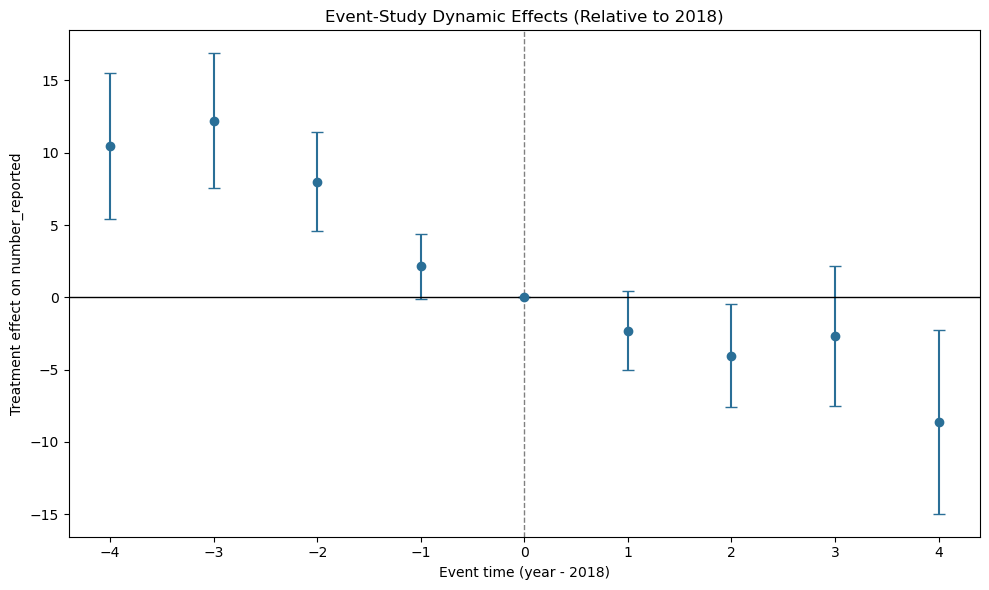

Saved plot: outputs/event_study_coefficients.png


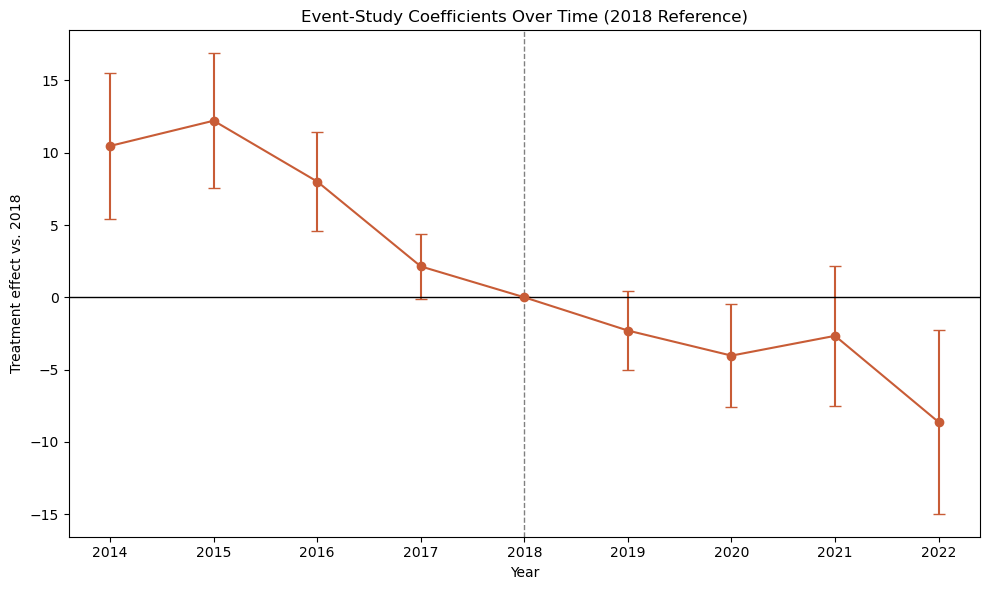

Saved plot: outputs/event_study_coefficients_by_year.png


In [27]:
# Plot 1: coefficients by event time relative to 2018.
plt.figure(figsize=(10, 6))
plt.errorbar(
    effects["event_time"],
    effects["coef"],
    yerr=1.96 * effects["se"],
    fmt="o",
    capsize=4,
    color="#2A6F97"
)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Event-Study Dynamic Effects (Relative to 2018)")
plt.xlabel("Event time (year - 2018)")
plt.ylabel("Treatment effect on number_reported")
plt.tight_layout()

plot_path_event_time = os.path.join(OUT_DIR, "event_study_coefficients.png")
plt.savefig(plot_path_event_time, dpi=300)
plt.show()
print(f"Saved plot: {plot_path_event_time}")

# Plot 2: same coefficients over calendar year, anchored at 2018.
plt.figure(figsize=(10, 6))
plt.errorbar(
    effects["year"],
    effects["coef"],
    yerr=1.96 * effects["se"],
    fmt="o-",
    capsize=4,
    color="#C85C36"
)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(2018, color="gray", linestyle="--", linewidth=1)
plt.title("Event-Study Coefficients Over Time (2018 Reference)")
plt.xlabel("Year")
plt.ylabel("Treatment effect vs. 2018")
plt.xticks(sorted(effects["year"].unique()))
plt.tight_layout()

plot_path_year = os.path.join(OUT_DIR, "event_study_coefficients_by_year.png")
plt.savefig(plot_path_year, dpi=300)
plt.show()
print(f"Saved plot: {plot_path_year}")

In [28]:
# Parallel trends check: pre-2018 coefficients (relative to 2018) should be close to zero.
pre = effects[effects["event_time"] < 0].copy()
pre_years = pre["year"].tolist()

if len(pre_years) == 0:
    print("No pre-2018 years available for pre-trends check.")
else:
    # Joint test: beta_preyear - beta_2018 = 0 for all pre years
    hypothesis_parts = []
    for y in pre_years:
        term_y = year_term.get(int(y))
        if term_y is not None:
            hypothesis_parts.append(f"{term_y} - {base_term} = 0")

    hypothesis = ", ".join(hypothesis_parts)
    wald = model.wald_test(hypothesis)

    print("Pre-2018 coefficients (each year relative to 2018):")
    display(pre[["year", "event_time", "coef", "se", "pvalue", "ci_low", "ci_high"]])
    print(f"Max |pre-2018 coef|: {pre['coef'].abs().max():.4f}")
    print(f"Joint Wald test p-value (all pre-effects relative to 2018 = 0): {wald.pvalue:.4g}")

    if wald.pvalue > 0.05:
        print("Conclusion: fail to reject pre-2018 effects = 0 (supports parallel trends).")
    else:
        print("Conclusion: reject pre-2018 effects = 0 (parallel trends may be violated).")

Pre-2018 coefficients (each year relative to 2018):


/Users/hejiang/opt/anaconda3/envs/floodproj/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,year,event_time,coef,se,pvalue,ci_low,ci_high
0,2014,-4,10.468496,2.580166,4.964438e-05,5.411370,15.525622
1,2015,-3,12.214674,2.376930,2.764344e-07,7.555890,16.873457
2,2016,-2,8.006085,1.745223,4.487371e-06,4.585449,11.426721
3,2017,-1,2.137758,1.156135,6.444978e-02,-0.128267,4.403783


Max |pre-2018 coef|: 12.2147
Joint Wald test p-value (all pre-effects relative to 2018 = 0): 1.998e-06
Conclusion: reject pre-2018 effects = 0 (parallel trends may be violated).


In [29]:
effects.to_csv(os.path.join(OUT_DIR, "event_study_coefficients.csv"), index=False)
print("Saved table:", os.path.join(OUT_DIR, "event_study_coefficients.csv"))

Saved table: outputs/event_study_coefficients.csv
